In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
from scipy.stats import spearmanr
import torch.nn.functional as F
import torch
import uncertainty_toolbox as uct
import seaborn as sns
from sklearn.metrics import mean_squared_error

e_scaling, e_shift = 0.06565926932648217, 6.6588702845000975
path_indices = '/home/riccardo/tmp/Data100/'
train_indices = np.genfromtxt(path_indices+'train_set_idxes.txt').astype(int)
valid_indices = np.genfromtxt(path_indices+'valid_set_idxes.txt').astype(int)
test_indices = np.genfromtxt(path_indices+'test_set_idxes.txt').astype(int)

def read(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    return [float(line.split('=')[1]) for line in lines if 'model.obs_scale' in line]

In [2]:
len(test_indices)

781

In [3]:
def analyze_uncertainty_and_error(y_true, y_pred, y_std):
    """
    Analyze uncertainty and error, compute quartile thresholds, and generate scatter plot.

    Parameters:
    y_true (numpy.ndarray): True values.
    y_pred (numpy.ndarray): Predicted values.
    y_std (numpy.ndarray): Standard deviations of predictions.

    Returns:
    float: Percentage of high-uncertainty points falling in the top error quartile.
    """
    errors = abs(y_true - y_pred)
    uncertainties = y_std

    # Compute quartile thresholds
    q3_error = np.percentile(errors, 75)
    q3_uncertainty = np.percentile(uncertainties, 75)

    # Boolean masks
    high_error = errors > q3_error
    high_uncertainty = uncertainties > q3_uncertainty
    high_both = high_error & high_uncertainty

    n_overlap = np.sum(high_both)
    n_high_uncertainty = np.sum(high_uncertainty)

    percent_overlap = 100 * n_overlap / n_high_uncertainty
   
    return percent_overlap

In [12]:
import glob
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path

points = {}
for run in sorted(glob.glob('DE/de_pred_100_*/runs/2025-05*', recursive=True)):
    run_name = run.split('/')[-1]
    points[run_name] = {}
    parquet_path = glob.glob(f"{run}/**/*.parquet", recursive=True)   
    
    y_preds = []
    print(parquet_path)
    for parquet in parquet_path:
        rs = pd.read_csv(parquet)
        n_atoms = rs['n_atoms'].to_numpy()
        y_true_all = (rs['true'].to_numpy()/e_scaling + n_atoms*e_shift)/n_atoms
        y_pred = (rs['preds'].to_numpy()/e_scaling + n_atoms*e_shift)/n_atoms
        y_preds.append(list(y_pred))
    y_pred_all = np.array(y_preds).mean(axis=0)
    y_std_all = np.std(y_preds, axis=0)
    
    for indices, split in zip([train_indices, valid_indices, test_indices], ['Train', 'Val', 'Test']):
        points[run_name][split] = {}
        y_true = y_true_all[indices]
        y_pred = y_pred_all[indices]
        y_std_scaled = y_std_all[indices]
        
        mae = mean_squared_error(y_true, y_pred)# float(np.mean(np.abs(y_true - y_pred)))
        nll_scaled = F.gaussian_nll_loss(
            torch.tensor(y_pred),
            torch.tensor(y_true),
            torch.square(torch.tensor(y_std_scaled))
        ).item()
        points[run_name][split] = [y_true, y_pred, y_std_scaled, mae, nll_scaled, n_atoms[indices]]

        # if split == 'Test':
        #     a = analyze_uncertainty_and_error(y_true, y_pred, y_std_scaled)
        #     mae = abs(y_true - y_pred).mean()
        #     print('de', 'big', a, mae)

['DE/de_pred_100_1/runs/2025-05-09_11-48-34/NN_007_val.parquet', 'DE/de_pred_100_1/runs/2025-05-09_11-48-34/NN_001_val.parquet', 'DE/de_pred_100_1/runs/2025-05-09_11-48-34/NN_002_val.parquet', 'DE/de_pred_100_1/runs/2025-05-09_11-48-34/NN_003_val.parquet', 'DE/de_pred_100_1/runs/2025-05-09_11-48-34/NN_004_val.parquet', 'DE/de_pred_100_1/runs/2025-05-09_11-48-34/NN_005_val.parquet', 'DE/de_pred_100_1/runs/2025-05-09_11-48-34/NN_000_val.parquet', 'DE/de_pred_100_1/runs/2025-05-09_11-48-34/NN_006_val.parquet', 'DE/de_pred_100_1/runs/2025-05-09_11-48-34/NN_009_val.parquet', 'DE/de_pred_100_1/runs/2025-05-09_11-48-34/NN_008_val.parquet']
['DE/de_pred_100_2/runs/2025-05-09_11-50-33/NN_007_val.parquet', 'DE/de_pred_100_2/runs/2025-05-09_11-50-33/NN_001_val.parquet', 'DE/de_pred_100_2/runs/2025-05-09_11-50-33/NN_002_val.parquet', 'DE/de_pred_100_2/runs/2025-05-09_11-50-33/NN_003_val.parquet', 'DE/de_pred_100_2/runs/2025-05-09_11-50-33/NN_004_val.parquet', 'DE/de_pred_100_2/runs/2025-05-09_11-5

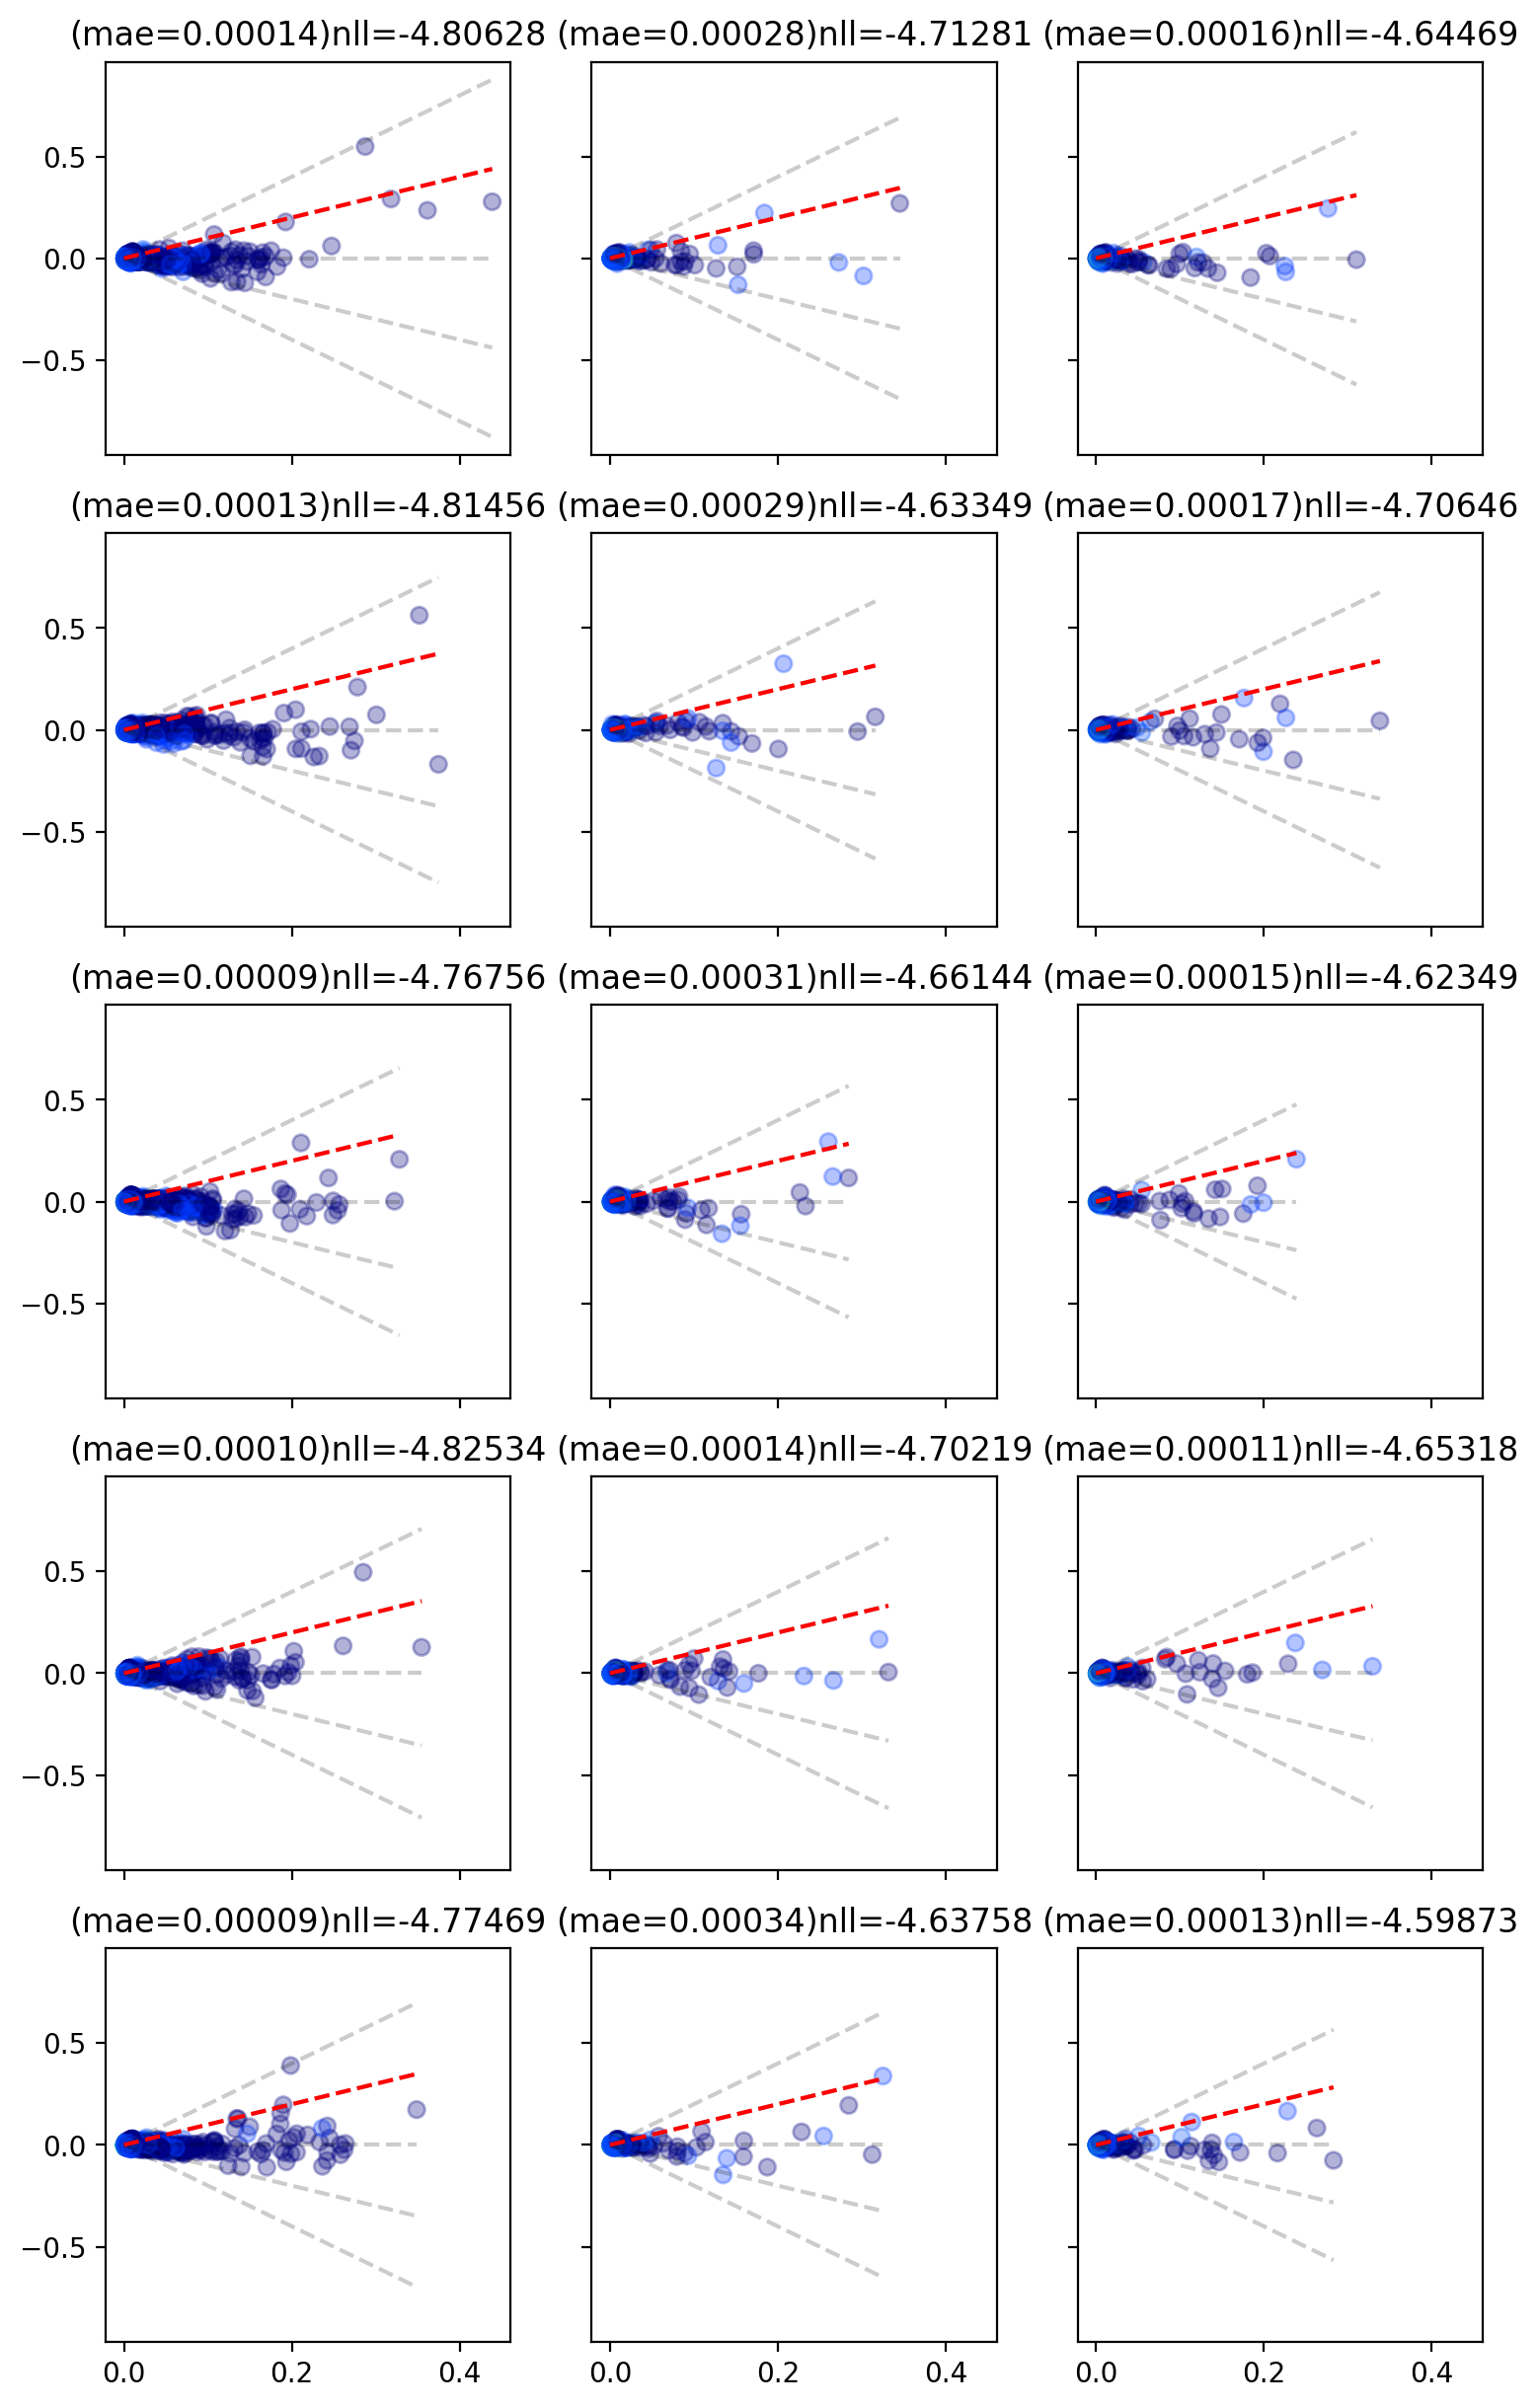

In [13]:
col, row = 3, 5
fig, ax = plt.subplots(row, col, figsize=(col*3, row*3), dpi=200, sharex=True, sharey=True)
#fig, ax = plt.subplots(3, 4, figsize=(12*0.8, 44/3*0.8), dpi=200)
ax = ax.flatten()
i = 0          

for run in points:
    for split in points[run]:
        y_true, y_pred, y_std_scaled, mae, nll_scaled, n_atoms = points[run][split]
        err = (y_true - y_pred)
        ax[i].scatter(y_std_scaled, err, alpha=0.3, c=n_atoms, cmap='jet')
        l = np.linspace(0, max(y_std_scaled), 100)
        for j in range(-2, 3):
            ax[i].plot(l, l*j, color='black', linestyle='--', alpha=0.2)
        ax[i].plot(l, l, color='red', linestyle='--')
        ax[i].set_title(f'(mae={mae:.5f})'
                            f'nll={nll_scaled:.5f}')
        # ax[i].set_xlim(min(y_std_scaled)-0.05, max(y_std_scaled))
        # ax[i].set_ylim(min(err)-0.05, max(err))
        i+= 1


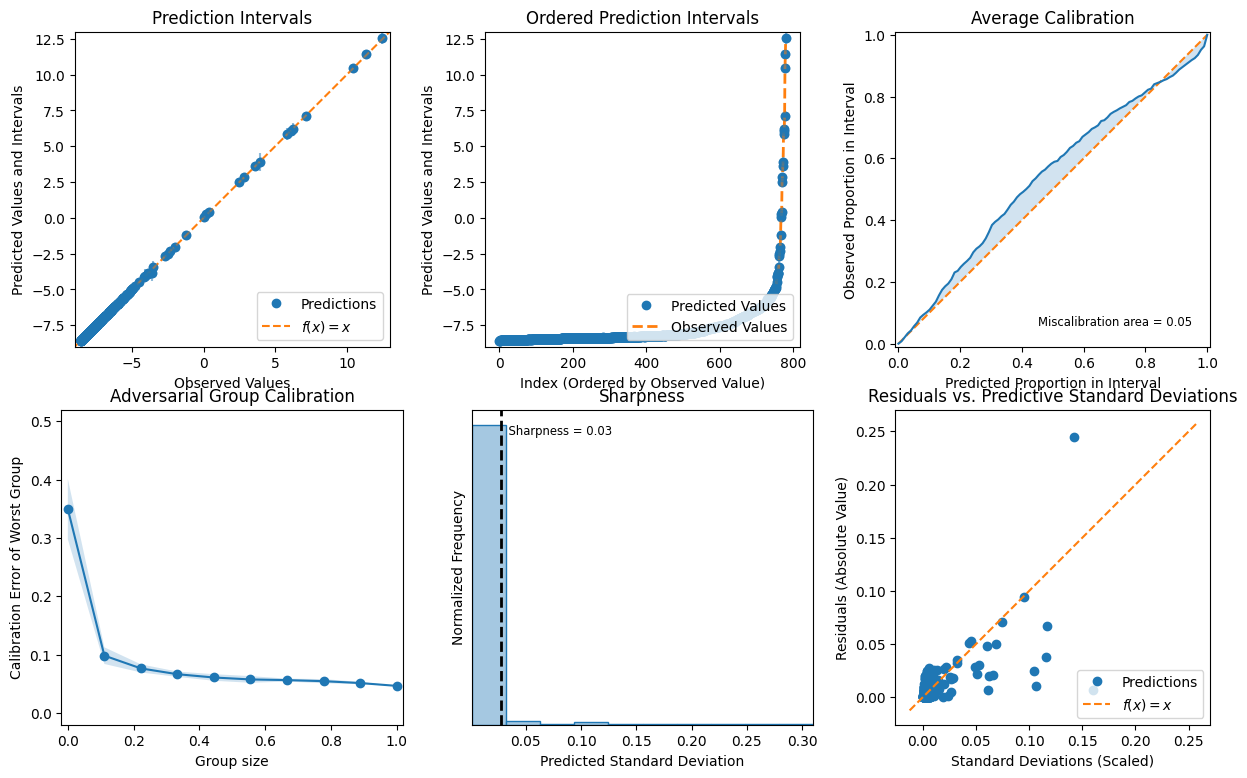

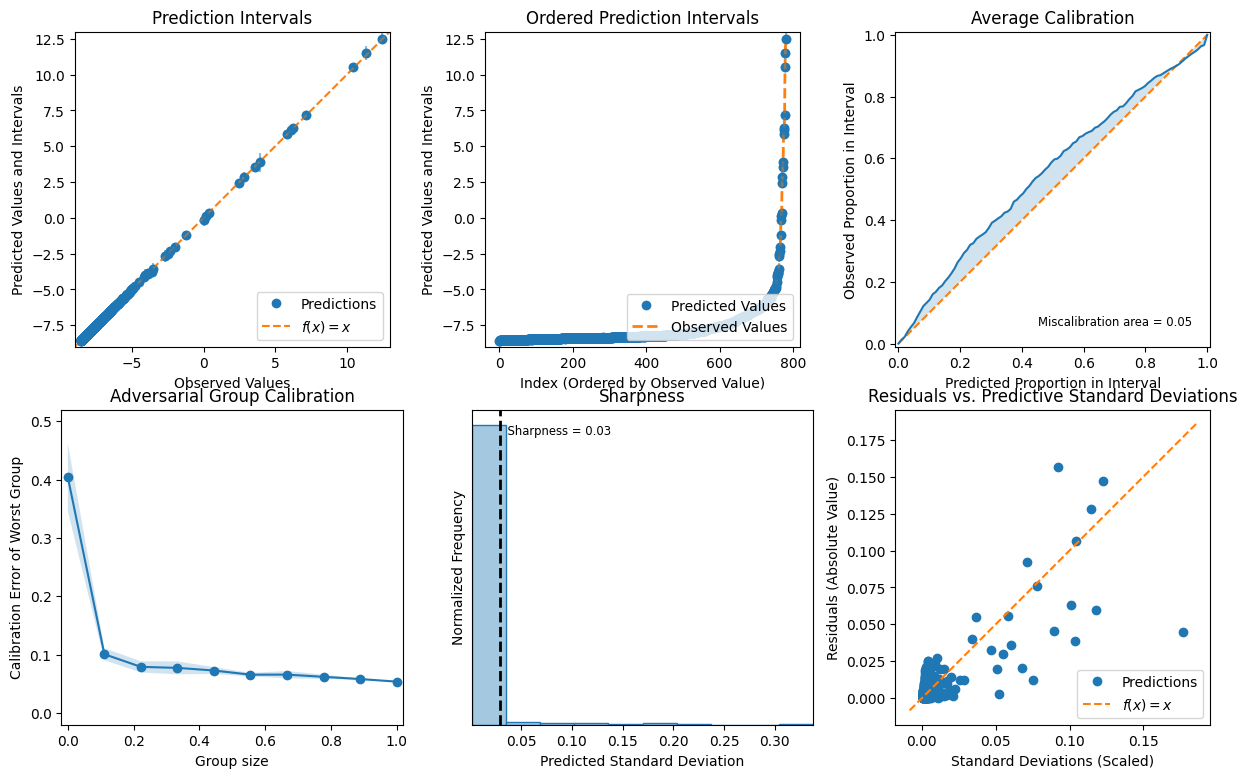

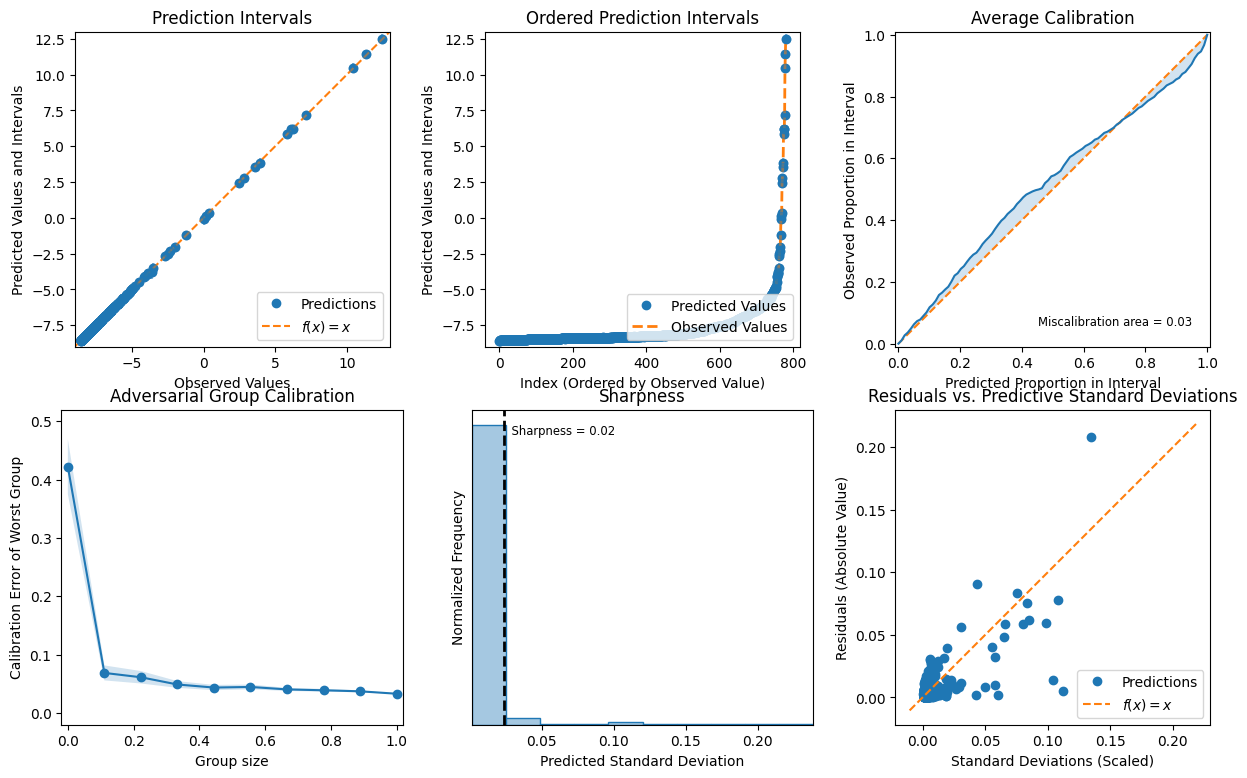

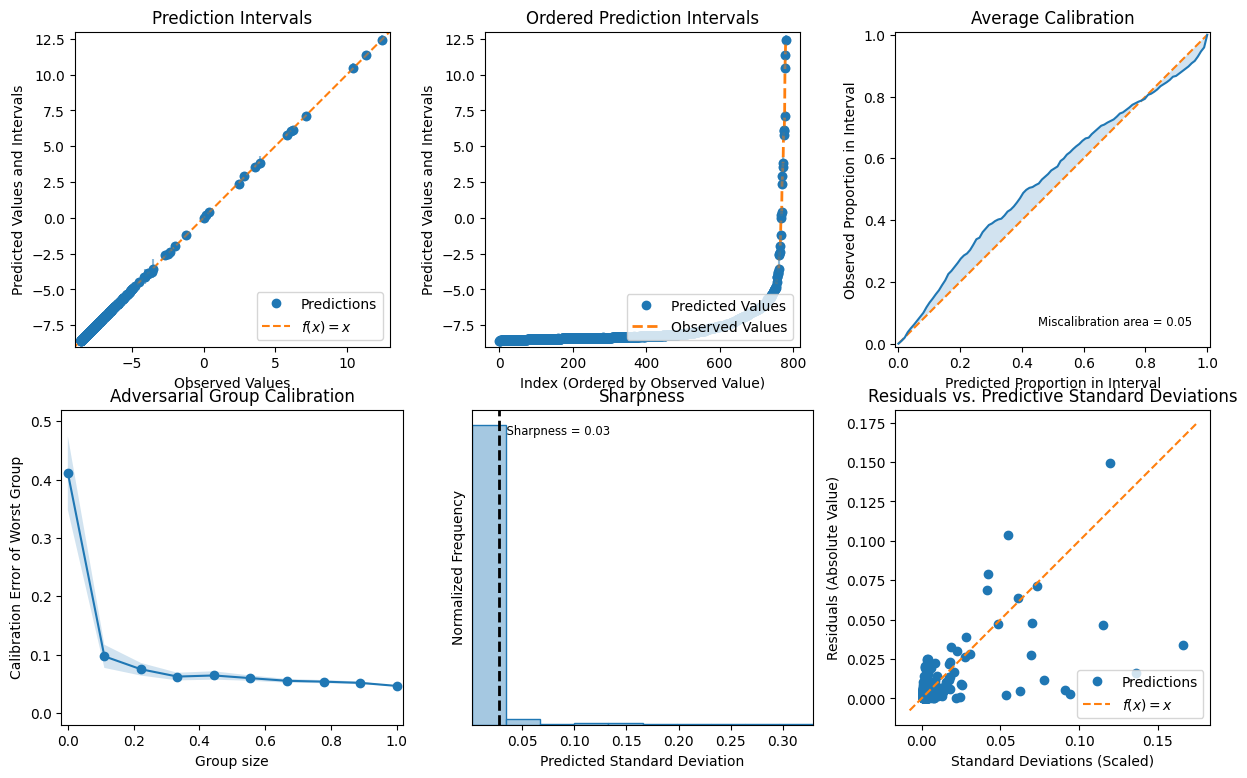

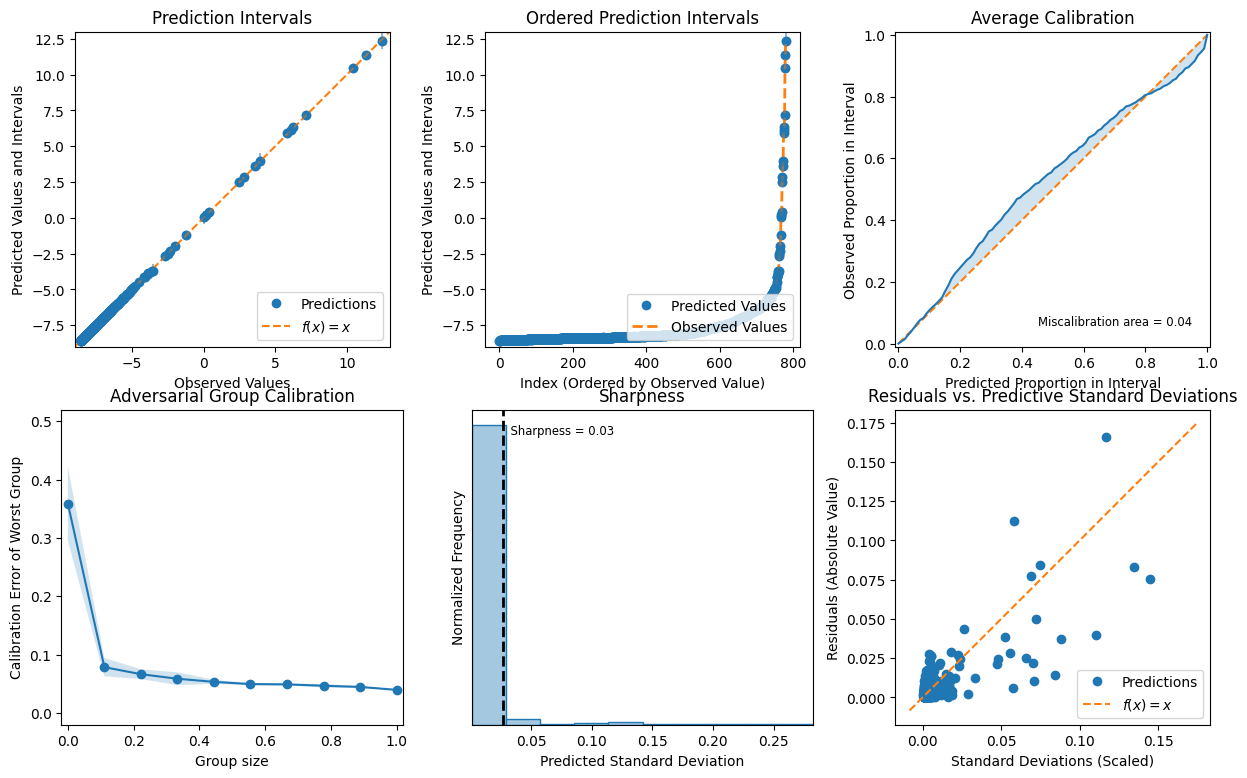

In [14]:
for run in points:
    y_true, y_pred, y_std, mae, nll_scaled, n_atoms = points[run]['Test']

    fig, ax = plt.subplots(2, 3, figsize=(15, 9))
    ax = ax.flat
    uct.plot_intervals(y_pred, y_std, y_true, ax=ax[0])
    uct.plot_intervals_ordered(y_pred, y_std, y_true, ax=ax[1])
    uct.plot_calibration(y_pred, y_std, y_true, ax=ax[2])
    uct.plot_adversarial_group_calibration(y_pred, y_std, y_true, ax=ax[3])
    uct.plot_sharpness(y_std, ax=ax[4])
    uct.plot_residuals_vs_stds(y_pred, y_std, y_true, ax=ax[5])

42.56% of high-uncertainty points fall in the top error quartile.


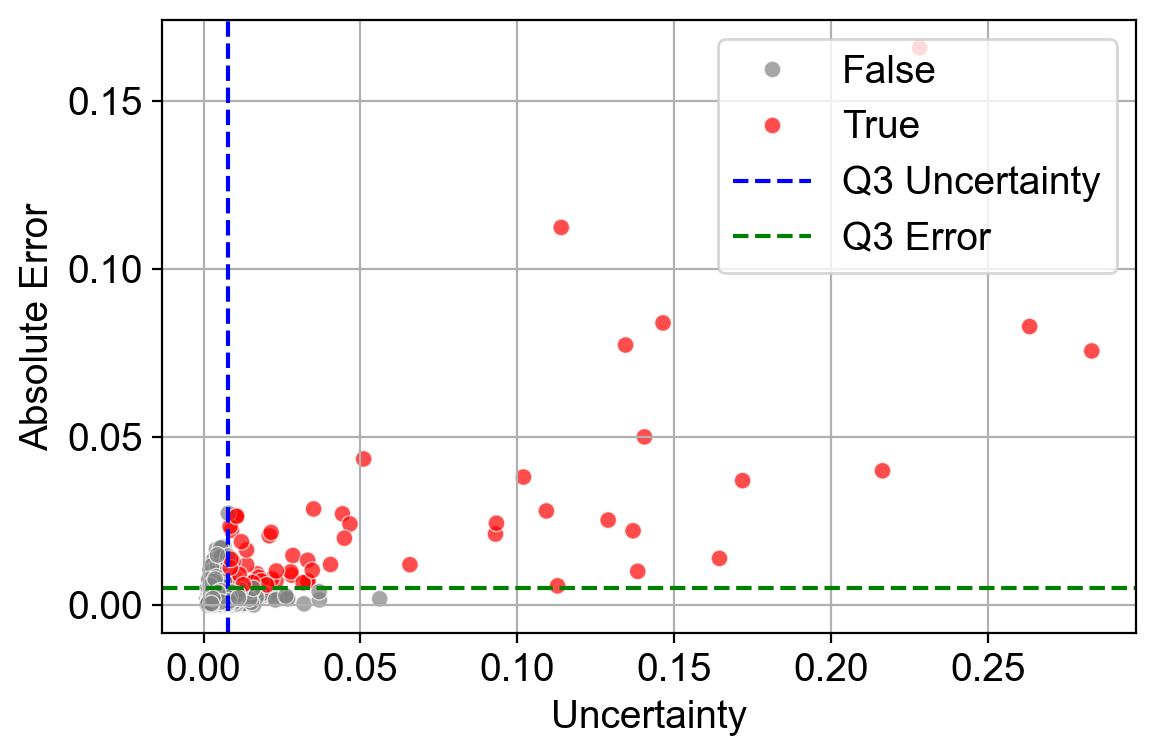

42.56410256410256

In [19]:
plt.rcParams.update({
"figure.dpi" : 200,
"font.family": "sans-serif",
"font.sans-serif": "Arial",
"font.size" : 14,
'mathtext.default':  'regular'
    })

def analyze_uncertainty_and_error(y_true, y_pred, y_std, save_path):
    """
    Analyze uncertainty and error, compute quartile thresholds, and generate scatter plot.

    Parameters:
    y_true (numpy.ndarray): True values.
    y_pred (numpy.ndarray): Predicted values.
    y_std (numpy.ndarray): Standard deviations of predictions.
    save_path (str): Path to save the generated plot.

    Returns:
    float: Percentage of high-uncertainty points falling in the top error quartile.
    """
    errors = abs(y_true - y_pred)
    uncertainties = y_std

    # Compute quartile thresholds
    q3_error = np.percentile(errors, 75)
    q3_uncertainty = np.percentile(uncertainties, 75)

    # Boolean masks
    high_error = errors > q3_error
    high_uncertainty = uncertainties > q3_uncertainty
    high_both = high_error & high_uncertainty

    n_overlap = np.sum(high_both)
    n_high_uncertainty = np.sum(high_uncertainty)

    percent_overlap = 100 * n_overlap / n_high_uncertainty
    print(f"{percent_overlap:.2f}% of high-uncertainty points fall in the top error quartile.")

    # Scatter plot with color coding
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=uncertainties, y=errors, hue=high_both, palette={True: "red", False: "gray"}, alpha=0.7)
    plt.axvline(q3_uncertainty, color='blue', linestyle='--', label='Q3 Uncertainty')
    plt.axhline(q3_error, color='green', linestyle='--', label='Q3 Error')
    # plt.title("Uncertainty vs Error with Top Quartile Highlight")
    plt.xlabel("Uncertainty")
    plt.ylabel("Absolute Error")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

    return percent_overlap

analyze_uncertainty_and_error(y_true, y_pred, y_std, 'overlap.png')

In [10]:
points

{'2025-03-11_10-24-21': {'Train': {}}}